# Gradient Descent Assignment — Curved Decision Boundaries

This notebook contains three problems (A, B, C). For each problem you will:
- implement the model and loss (student cells marked with `# YOUR CODE HERE`),
- run gradient descent on the client, and
- visualize two plots side-by-side: feature space (points + decision boundary) and a slice of the loss landscape (loss over w1,w2) with a moving marker for the optimizer.

Cells marked `# SOLUTION` contain working reference solutions. Run cells in order.

## Common imports and helpers

We provide plotting helpers used by all problems.

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

from app.datasets import get_dataset
from app.functions import quadratic_binary_loss, quadratic_binary_grad, quadratic_predict_proba

plt.rcParams.update({"figure.max_open_warning": 0})

def plot_feature_and_loss(params, X, y, loss_fn, predict_proba_fn, w_idx=(1,2), grid_radius=2.5, ax_left=None, ax_right=None):
    """Draw feature scatter + decision boundary (left) and loss landscape over w_idx (right).
    params: 1D array of current parameters
    w_idx: tuple of indices to vary on the right plot (typically the linear coefficients)
    """
    p = np.asarray(params, dtype=float).copy()
    if ax_left is None or ax_right is None:
        fig, (ax_left, ax_right) = plt.subplots(1,2, figsize=(10,5))
    else:
        fig = ax_left.figure

    ax_left.clear(); ax_right.clear()
    # Feature space
    ax_left.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', s=25, edgecolor='k')
    # decision boundary by contouring f(x,y)=0 on a mesh
    xs = np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 200)
    ys = np.linspace(X[:,1].min()-0.5, X[:,1].max()+0.5, 200)
    XX, YY = np.meshgrid(xs, ys)
    grid = np.column_stack([XX.ravel(), YY.ravel()])
    probs = predict_proba_fn(p, grid)
    ZZ = probs.reshape(XX.shape)
    # contour at 0.5 probability -> decision boundary f=0
    cs = ax_left.contour(XX, YY, ZZ, levels=[0.5], colors=['k'])
    ax_left.set_title('Feature space (points + decision boundary)')

    # Loss landscape over two parameter indices
    i, j = w_idx
    center_i, center_j = p[i], p[j]
    grid_vals = np.linspace(center_i - grid_radius, center_i + grid_radius, 120)
    Gx, Gy = np.meshgrid(grid_vals, grid_vals)
    losses = np.empty_like(Gx)
    for a in range(Gx.shape[0]):
        for b in range(Gx.shape[1]):
            q = p.copy()
            q[i] = Gx[a,b]
            q[j] = Gy[a,b]
            losses[a,b] = loss_fn(q)
    im = ax_right.imshow(losses, extent=(grid_vals.min(), grid_vals.max(), grid_vals.min(), grid_vals.max()), origin='lower', cmap='viridis')
    ax_right.set_xlabel(f'w[{i}]')
    ax_right.set_ylabel(f'w[{j}]')
    ax_right.set_title('Loss landscape (slice)')
    # draw current point
    ax_right.scatter([p[i]], [p[j]], color='red', s=50)
    fig.colorbar(im, ax=ax_right)
    plt.tight_layout()
    return fig, ax_left, ax_right

def animate_history(history, X, y, loss_fn, predict_proba_fn, w_idx=(1,2), delay=0.2):
    for p in history:
        fig, axl, axr = plot_feature_and_loss(p, X, y, loss_fn, predict_proba_fn, w_idx=w_idx)
        clear_output(wait=True)
        display(fig)
        plt.close(fig)
        time.sleep(delay)


## Problem A — Linear separator (3 parameters)

Model: f(x,y) = b + w1*x + w2*y. 3 parameters: [b, w1, w2]. Students should predict what happens when optimizing these with gradient descent on the binary cross-entropy loss.

In [ ]:
# YOUR CODE HERE: implement linear model, loss, numeric grad and optional auto-grad
import numpy as np
from typing import Callable

def linear_design_matrix(X: np.ndarray) -> np.ndarray:
    ones = np.ones((X.shape[0], 1))
    return np.hstack([ones, X])

def predict_proba_linear(params: np.ndarray, X: np.ndarray) -> np.ndarray:
    """Return probability sigmoid(b + w1*x + w2*y)"""
    # YOUR CODE HERE
    raise NotImplementedError()

def bce_loss(params: np.ndarray, X: np.ndarray, y: np.ndarray) -> float:
    """Binary cross-entropy loss for given params on X,y"""
    # YOUR CODE HERE
    raise NotImplementedError()

def numeric_grad(f: Callable[[np.ndarray], float], params: np.ndarray, eps=1e-6) -> np.ndarray:
    grad = np.zeros_like(params)
    for k in range(len(params)):
        p1 = params.copy(); p1[k] += eps
        p2 = params.copy(); p2[k] -= eps
        grad[k] = (f(p1) - f(p2)) / (2*eps)
    return grad

# (Optional) try to use jax if available for auto-grad; otherwise students may use numeric_grad
try:
    import jax
    import jax.numpy as jnp
    from jax import grad as jax_grad
    def autograd_grad(f, params):
        jf = lambda p: f(np.asarray(p))
        return np.asarray(jax_grad(lambda q: jf(np.array(q)))(params))
except Exception:
    jax = None
    def autograd_grad(f, params):
        raise RuntimeError('jax not available; use numeric_grad')


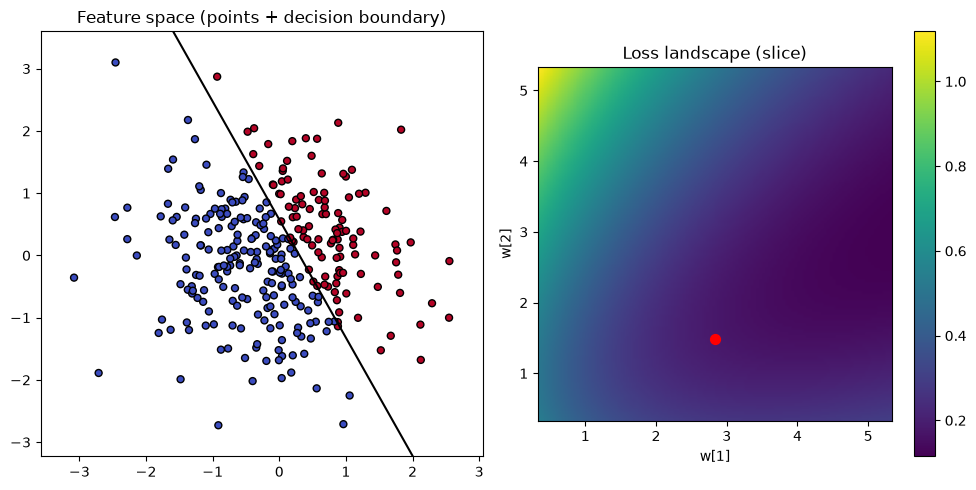

In [ ]:
# SOLUTION
from math import exp
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def predict_proba_linear(params: np.ndarray, X: np.ndarray) -> np.ndarray:
    Phi = linear_design_matrix(X)
    return sigmoid(Phi @ params)

def bce_loss(params: np.ndarray, X: np.ndarray, y: np.ndarray) -> float:
    probs = predict_proba_linear(params, X)
    eps = 1e-12
    probs = np.clip(probs, eps, 1-eps)
    return float(-np.mean(y * np.log(probs) + (1-y) * np.log(1-probs)))

def analytic_grad_linear(params: np.ndarray, X: np.ndarray, y: np.ndarray) -> np.ndarray:
    Phi = linear_design_matrix(X)
    probs = predict_proba_linear(params, X)
    return (Phi.T @ (probs - y)) / len(y)

# small helper to run gradient descent and collect history
def run_gd(loss_fn, grad_fn, init_params, lr=0.5, steps=60):
    p = init_params.copy()
    hist = [p.copy()]
    for t in range(steps):
        g = grad_fn(p)
        p = p - lr * g
        hist.append(p.copy())
    return hist

# Load a simple dataset for linear separable-ish demonstration
rng = np.random.default_rng(1)
n = 300
X = rng.normal(scale=1.0, size=(n,2))
y = (X[:,0] + 0.5*X[:,1] > 0.3).astype(int)

# initialize params
init = np.array([0.0, 0.0, 0.0])
loss_fn = lambda p: bce_loss(p, X, y)
grad_fn = lambda p: analytic_grad_linear(p, X, y)
history = run_gd(loss_fn, grad_fn, init, lr=0.5, steps=60)
animate_history(history, X, y, lambda q: bce_loss(q, X, y), lambda q,x: predict_proba_linear(q, x), w_idx=(1,2), delay=0.05)


## Problem B — Quadratic separator (6 parameters)

Model: f(x,y) = b + w1*x + w2*y + w11*x^2 + w22*y^2 + w12*x*y. 6 parameters: [b, w1, w2, w11, w22, w12].
This uses the hidden concentric-rings dataset (non-linearly separable) to demonstrate a curved boundary.

In [ ]:
# YOUR CODE HERE: implement quadratic model interface using available helpers
from app.datasets import get_dataset
Xq, yq = get_dataset('quadratic_binary')

def predict_proba_quadratic(params: np.ndarray, X: np.ndarray) -> np.ndarray:
    # YOUR CODE HERE
    raise NotImplementedError()

def loss_quadratic(params: np.ndarray) -> float:
    # YOUR CODE HERE
    raise NotImplementedError()

def grad_quadratic(params: np.ndarray) -> np.ndarray:
    # YOUR CODE HERE
    raise NotImplementedError()


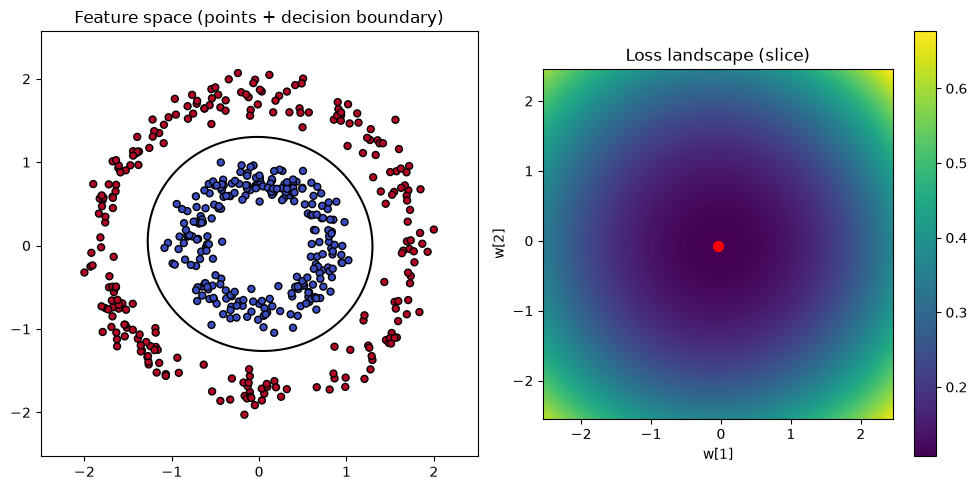

In [ ]:
# SOLUTION — quadratic using implemented helpers in app.functions
from app.functions import quadratic_binary_loss, quadratic_binary_grad, quadratic_predict_proba

def predict_proba_quadratic(params: np.ndarray, X: np.ndarray) -> np.ndarray:
    return quadratic_predict_proba(params, X)

def loss_quadratic(params: np.ndarray) -> float:
    return quadratic_binary_loss(params)

def grad_quadratic(params: np.ndarray) -> np.ndarray:
    return np.asarray(quadratic_binary_grad(params))

# run gradient descent from small random init
rng = np.random.default_rng(42)
init_q = rng.normal(scale=0.1, size=6)
history_q = []
p = init_q.copy()
history_q.append(p.copy())
lr = 0.5
for t in range(80):
    g = grad_quadratic(p)
    p = p - lr * g
    history_q.append(p.copy())

# visualize
animate_history(history_q, Xq, yq, lambda q: loss_quadratic(q), lambda q,X: predict_proba_quadratic(q,X), w_idx=(1,2), delay=0.05)


## Problem C — Radial-basis separator (10-20 parameters)

This is an optional extension: build RBF features (e.g. 8 centres) and learn a linear classifier on top. The idea is to increase parameter count so students see how the boundary can become more complex.
Implement as an exercise (skeleton below).


In [ ]:
# YOUR CODE HERE: Problem C skeleton
def rbf_features(X, centers, gamma=5.0):
    # X: (n,2), centers: (m,2) -> returns (n, m) features
    # YOUR CODE HERE
    raise NotImplementedError()

def train_rbf():
    # build centers (e.g. by kmeans or grid), create features, and fit using gradient descent on BCE
    pass
